# Plant Disease Model — Evaluation Notebook

This notebook evaluates the model trained by `Plant_Disease_Model3.ipynb`.
All parameters and dataset loading match the training notebook exactly.

Key defaults (must match training):
- Image size: `224×224` (RGB, 3 channels)
- `label_mode="categorical"`, `interpolation="bilinear"`
- No `.cache()` — only `.prefetch()` to avoid RAM overflow
- Class names are inferred from directory structure

## Setup

In [1]:
# Mount Google Drive where the trained model and outputs are stored
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Optional: download dataset in a fresh environment. Uncomment as needed.

import os
os.makedirs("/root/.kaggle", exist_ok=True)
!pip install kaggle==1.6.17
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip /content/new-plant-diseases-dataset.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: /content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: /content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: /content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: /content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665_270deg.JPG  
  inflatin

## Imports and Parameters

All hyperparameters and paths mirror `Plant_Disease_Model3.ipynb` exactly so the datasets are loaded identically.

In [29]:
import os
import csv
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, roc_curve, auc, precision_recall_curve,
)
from sklearn.preprocessing import label_binarize

sns.set_theme(style="whitegrid")

# ── Parameters (must match Plant_Disease_Model3.ipynb exactly) ────────────
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 8
COLOR_MODE   = "rgb"
NUM_CHANNELS = 3
SEED         = 42
AUTOTUNE     = tf.data.AUTOTUNE

# Mixed precision — same policy as training
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# ── Paths ─────────────────────────────────────────────────────────────────
DATASET_ROOT = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
TRAIN_DIR    = os.path.join(DATASET_ROOT, "train")
VAL_DIR      = os.path.join(DATASET_ROOT, "valid")
TEST_DIR     = "/content/drive/MyDrive/test/test_set"

OUTPUT_DIR   = Path("/content/drive/MyDrive/plant_outputs_cnn")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EVAL_OUTPUT_DIR = OUTPUT_DIR / "eval_results"
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUT_DIR / "best_plant_model.keras"

print("TensorFlow version:", tf.__version__)
print(f"Output directory (Google Drive): {OUTPUT_DIR}")
print(f"Eval output directory: {EVAL_OUTPUT_DIR}")
print("Image size:", IMG_SIZE)
print("Color mode:", COLOR_MODE)
print(f"Batch size: {BATCH_SIZE}")
print(f"Mixed precision policy: {mixed_precision.global_policy().name}")

TensorFlow version: 2.19.0
Output directory (Google Drive): /content/drive/MyDrive/plant_outputs_cnn
Eval output directory: /content/drive/MyDrive/plant_outputs_cnn/eval_results
Image size: (224, 224)
Color mode: rgb
Batch size: 8
Mixed precision policy: mixed_float16


## Load Datasets

Uses the same `load_dataset` helper and parameters as the training notebook.
No `.cache()` — only `.prefetch()` to avoid ~20 GB RAM crash on Colab.

In [46]:
def load_dataset(split_dir, shuffle):
    """Identical to the load_dataset function in Plant_Disease_Model3.ipynb."""
    ds = tf.keras.utils.image_dataset_from_directory(
        split_dir,
        labels="inferred",
        label_mode="categorical",
        color_mode=COLOR_MODE,
        batch_size=BATCH_SIZE,
        image_size=IMG_SIZE,
        shuffle=shuffle,
        seed=SEED if shuffle else None,
        interpolation="bilinear",
    )
    # NOTE: class_names must be read BEFORE .prefetch() — the
    # _PrefetchDataset wrapper does not expose that attribute.
    class_names = ds.class_names
    return ds.prefetch(AUTOTUNE), class_names


raw_training_set,   class_names = load_dataset(TRAIN_DIR, shuffle=False)
raw_validation_set, _           = load_dataset(VAL_DIR,   shuffle=False)
raw_test_set, _               = load_dataset(TEST_DIR,  shuffle=False)

num_classes = len(class_names)

training_set   = raw_training_set
validation_set = raw_validation_set
test_set       = raw_test_set   # use validation as test (same as training notebook)

print("Classes:",          class_names)
print("Number of classes:", num_classes)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Found 128 files belonging to 38 classes.
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato__

In [47]:
# Quick sanity check — should print (8, 224, 224, 3) to confirm parameters match training
sample_images, sample_labels = next(iter(training_set))
print("Batch images shape:", sample_images.shape)   # expect (8, 224, 224, 3)
print("Batch labels shape:", sample_labels.shape)   # expect (8, 38)
print("Pixel dtype:",        sample_images.dtype)
print("Raw pixel range:",    float(tf.reduce_min(sample_images)), "to",
                             float(tf.reduce_max(sample_images)))

Batch images shape: (8, 224, 224, 3)
Batch labels shape: (8, 38)
Pixel dtype: <dtype: 'float32'>
Raw pixel range: 0.0 to 255.0


## Load Trained Model

In [48]:
model = tf.keras.models.load_model(str(MODEL_PATH))
print("Model loaded from:", MODEL_PATH)
model.summary()

Model loaded from: /content/drive/MyDrive/plant_outputs_cnn/best_plant_model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 62 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 58 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "plant_disease_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ plant_augmentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_0_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             

 Total params: 3,748,248 (14.30 MB)

 Trainable params: 1,248,774 (4.76 MB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 2,497,554 (9.53 MB)

## Evaluate on All Splits

In [49]:
train_metrics = model.evaluate(training_set,   return_dict=True, verbose=1)
val_metrics   = model.evaluate(validation_set, return_dict=True, verbose=1)
test_metrics  = model.evaluate(test_set,       return_dict=True, verbose=1)

print("\nTrain metrics:     ", train_metrics)
print("Validation metrics:", val_metrics)
print("Test metrics:      ", test_metrics)

8787/8787 ━━━━━━━━━━━━━━━━━━━━ 164s 19ms/step - accuracy: 0.9978 - loss: 0.4222
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9953 - loss: 0.4290
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9844 - loss: 0.4503

Train metrics:      {'accuracy': 0.9977665543556213, 'loss': 0.4222140908241272}
Validation metrics: {'accuracy': 0.9953334927558899, 'loss': 0.4289659261703491}
Test metrics:       {'accuracy': 0.984375, 'loss': 0.45025089383125305}


In [50]:
def make_serializable(obj):
    if isinstance(obj, tf.Tensor):  return obj.numpy().tolist()
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, dict):       return {k: make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [make_serializable(v) for v in obj]
    return obj

def save_json(data, path):
    with open(path, "w", encoding="utf-8") as fh:
        json.dump(make_serializable(data), fh, indent=2)

def save_metrics_csv(metrics_dict, path):
    rows = [{"metric": k, "value": v} for k, v in metrics_dict.items()]
    pd.DataFrame(rows).to_csv(path, index=False)

split_metrics = {"train": train_metrics, "validation": val_metrics, "test": test_metrics}
for split_name, metrics in split_metrics.items():
    save_json(metrics,            EVAL_OUTPUT_DIR / f"{split_name}_metrics.json")
    save_metrics_csv(metrics,     EVAL_OUTPUT_DIR / f"{split_name}_metrics.csv")

print("Metrics saved to:", EVAL_OUTPUT_DIR)

Metrics saved to: /content/drive/MyDrive/plant_outputs_cnn/eval_results


## Predictions and Advanced Metrics

In [51]:
y_pred_proba = model.predict(test_set, verbose=0)

y_true_list = []
for _, labels in test_set:
    if hasattr(labels, 'numpy'):
        labels = labels.numpy()
    y_true_list.append(labels)

y_true_array = np.concatenate(y_true_list, axis=0)
y_true = np.argmax(y_true_array, axis=1)
y_pred = np.argmax(y_pred_proba, axis=1)

print("Prediction probability shape:", y_pred_proba.shape)
print("True label shape:",             y_true.shape)

save_json(y_pred_proba, EVAL_OUTPUT_DIR / "y_pred_proba.json")
save_json(y_true,       EVAL_OUTPUT_DIR / "y_true.json")
save_json(y_pred,       EVAL_OUTPUT_DIR / "y_pred.json")

Prediction probability shape: (128, 38)
True label shape: (128,)


In [52]:
balanced_acc  = balanced_accuracy_score(y_true, y_pred)
matthews_cc   = matthews_corrcoef(y_true, y_pred)
cohens_kappa  = cohen_kappa_score(y_true, y_pred)

print("=" * 60)
print("ADVANCED METRICS SUMMARY (Test Set)")
print("=" * 60)
print(f"Balanced Accuracy:               {balanced_acc:.4f}")
print(f"Matthews Correlation Coefficient:{matthews_cc:.4f}")
print(f"Cohen's Kappa:                   {cohens_kappa:.4f}")

cm_arr = confusion_matrix(y_true, y_pred)

sensitivity_per_class = {}
specificity_per_class = {}
precision_per_class   = {}

for i, class_name in enumerate(class_names):
    tp = cm_arr[i, i]
    fn = cm_arr[i, :].sum() - tp
    fp = cm_arr[:, i].sum() - tp
    tn = cm_arr.sum() - tp - fn - fp
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    sensitivity_per_class[class_name] = sensitivity
    specificity_per_class[class_name] = specificity
    precision_per_class[class_name]   = precision
    print(f"{class_name}: Sensitivity={sensitivity:.4f}  Specificity={specificity:.4f}  Precision={precision:.4f}")

advanced_metrics_df = pd.DataFrame({
    "Class":       class_names,
    "Sensitivity": [sensitivity_per_class[cn] for cn in class_names],
    "Specificity": [specificity_per_class[cn] for cn in class_names],
    "Precision":   [precision_per_class[cn]   for cn in class_names],
})
advanced_metrics_df["F2-Score"] = (
    5 * advanced_metrics_df["Precision"] * advanced_metrics_df["Sensitivity"]
    / (4 * advanced_metrics_df["Precision"] + advanced_metrics_df["Sensitivity"])
).fillna(0)
advanced_metrics_df.to_csv(EVAL_OUTPUT_DIR / "advanced_metrics_per_class.csv", index=False)

try:
    auc_scores = roc_auc_score(y_true, y_pred_proba, multi_class="ovr", average=None)
    macro_auc  = np.mean(auc_scores)
    print(f"\nAUC Scores (One-vs-Rest):")
    for cn, a in zip(class_names, auc_scores):
        print(f"  {cn}: {a:.5f}")
    print(f"Macro-average AUC: {macro_auc:.5f}")
except Exception as e:
    print(f"Note: AUC computation skipped ({e})")

ADVANCED METRICS SUMMARY (Test Set)
Balanced Accuracy:               0.9868
Matthews Correlation Coefficient:0.9841
Cohen's Kappa:                   0.9839
Apple___Apple_scab: Sensitivity=1.0000  Specificity=1.0000  Precision=1.0000
Apple___Black_rot: Sensitivity=1.0000  Specificity=1.0000  Precision=1.0000
Apple___Cedar_apple_rust: Sensitivity=1.0000  Specificity=1.0000  Precision=1.0000
Apple___healthy: Sensitivity=1.0000  Specificity=1.0000  Precision=1.0000
Blueberry___healthy: Sensitivity=1.0000  Specificity=1.0000  Precision=1.0000
Cherry_(including_sour)___Powdery_mildew: Sensitivity=1.0000  Specificity=1.0000  Precision=1.0000
Cherry_(including_sour)___healthy: Sensitivity=1.0000  Specificity=1.0000  Precision=1.0000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: Sensitivity=0.6667  Specificity=1.0000  Precision=1.0000
Corn_(maize)___Common_rust_: Sensitivity=1.0000  Specificity=1.0000  Precision=1.0000
Corn_(maize)___Northern_Leaf_Blight: Sensitivity=1.0000  Specificity=0

## Classification Report

In [53]:
class_report_text = classification_report(y_true, y_pred, target_names=class_names)
class_report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

print(class_report_text)

def save_classification_csv(report_dict, path):
    rows = []
    for label, metrics in report_dict.items():
        if label == "accuracy":
            rows.append({"class": "accuracy", "precision": "", "recall": "",
                         "f1_score": metrics, "support": ""})
            continue
        rows.append({"class": label, "precision": metrics["precision"],
                     "recall": metrics["recall"], "f1_score": metrics["f1-score"],
                     "support": metrics["support"]})
    pd.DataFrame(rows).to_csv(path, index=False)

save_json(class_report_dict,              EVAL_OUTPUT_DIR / "classification_report.json")
save_classification_csv(class_report_dict, EVAL_OUTPUT_DIR / "classification_report.csv")

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00         3
                                 Apple___Black_rot       1.00      1.00      1.00         5
                          Apple___Cedar_apple_rust       1.00      1.00      1.00         4
                                   Apple___healthy       1.00      1.00      1.00         3
                               Blueberry___healthy       1.00      1.00      1.00         3
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00         3
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00         3
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       1.00      0.67      0.80         3
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00         3
               Corn_(maize)___Northern_Leaf_Blight       0.75      1.00      0.

## Confusion Matrix

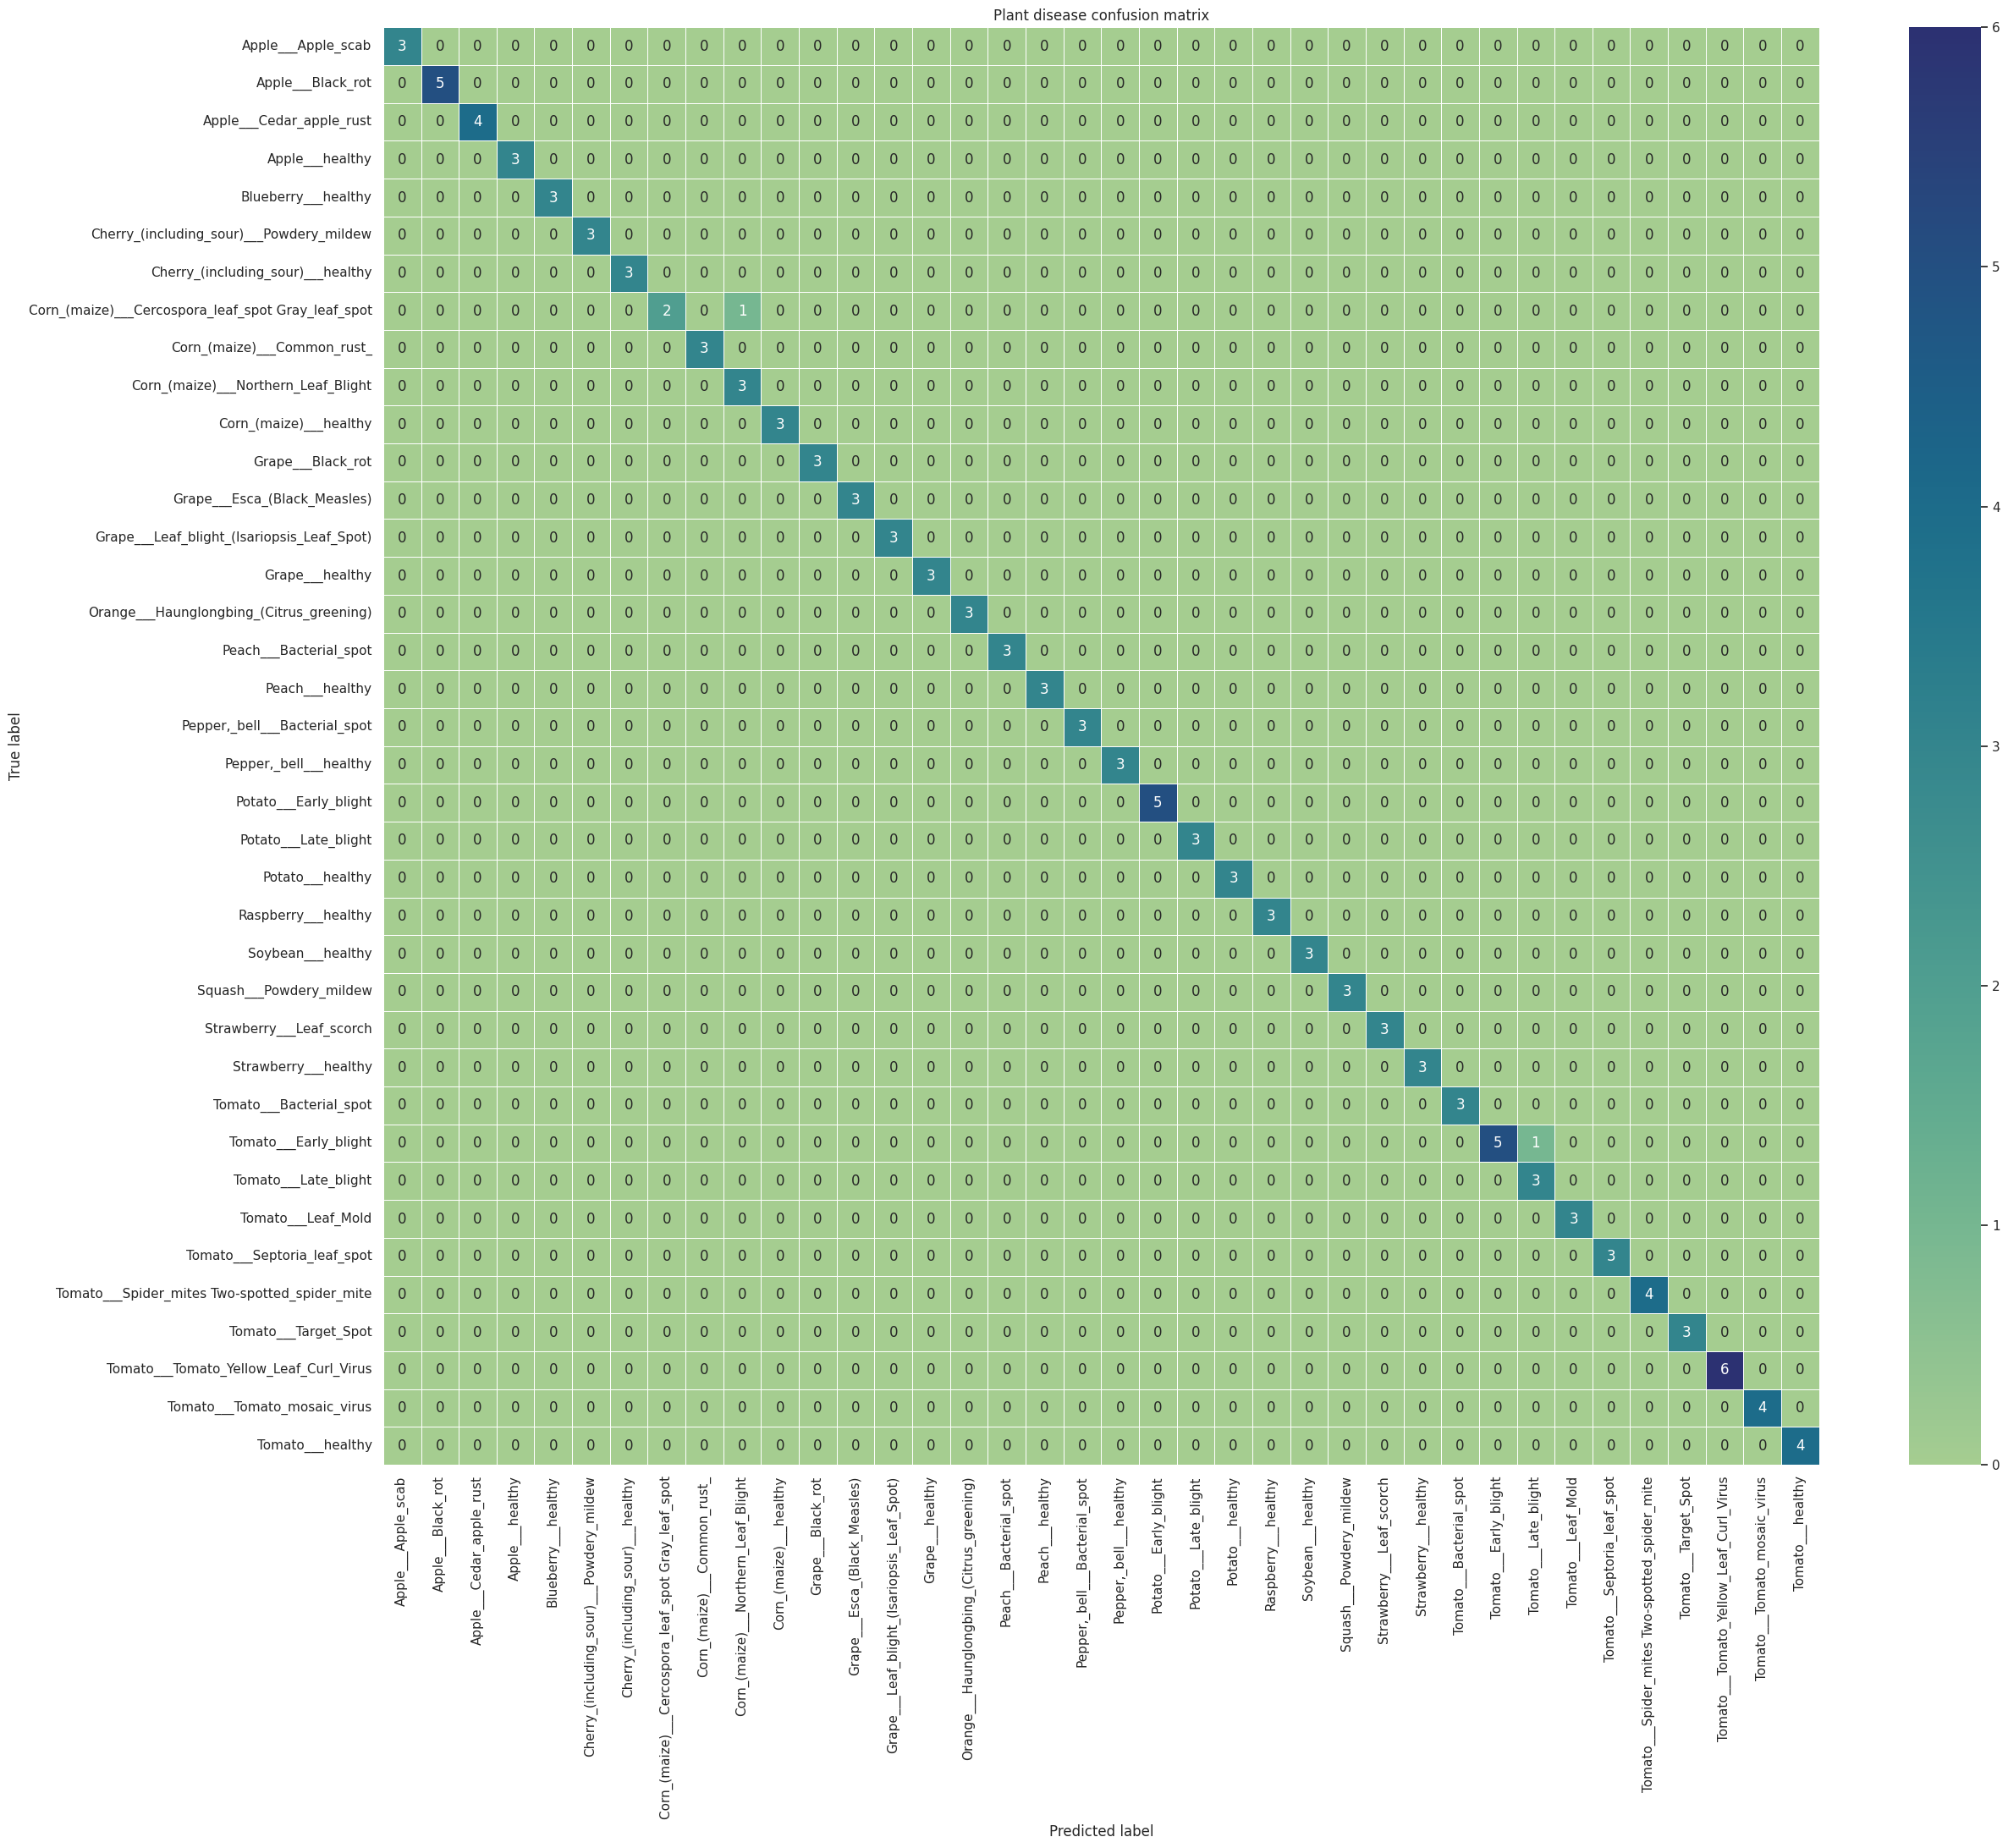

In [54]:
cm_df = pd.DataFrame(cm_arr, index=class_names, columns=class_names)
cm_df.to_csv(EVAL_OUTPUT_DIR / "confusion_matrix.csv")

plt.figure(figsize=(26, 22))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="crest", linewidths=0.5)
plt.title("Plant disease confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig(EVAL_OUTPUT_DIR / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## ROC and Precision-Recall Curves

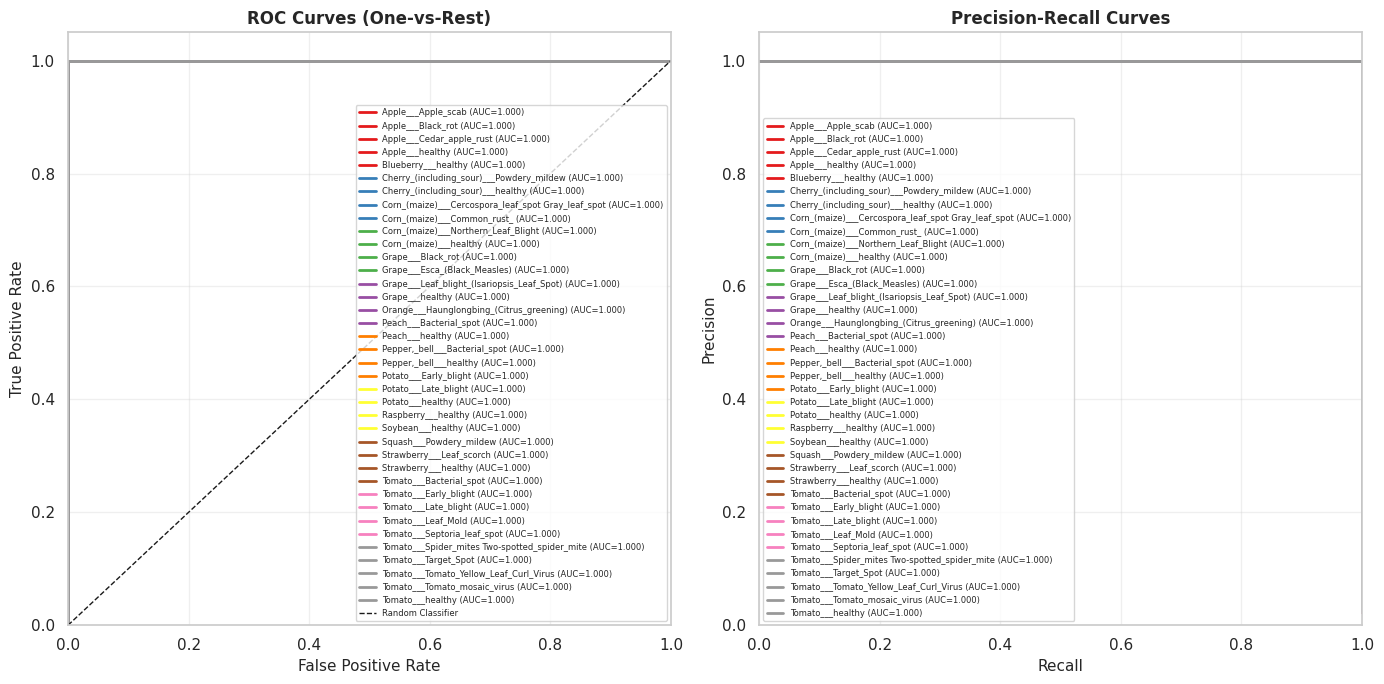

In [55]:
y_true_bin = label_binarize(y_true, classes=range(num_classes))
colors = plt.cm.Set1(np.linspace(0, 1, num_classes))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for i, cn in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=colors[i], lw=2, label=f"{cn} (AUC={roc_auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
axes[0].set_xlim([0.0, 1.0]); axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate",  fontsize=11)
axes[0].set_title("ROC Curves (One-vs-Rest)", fontsize=12, fontweight="bold")
axes[0].legend(loc="lower right", fontsize=6)
axes[0].grid(alpha=0.3)

for i, cn in enumerate(class_names):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_pred_proba[:, i])
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, color=colors[i], lw=2, label=f"{cn} (AUC={pr_auc:.3f})")

axes[1].set_xlim([0.0, 1.0]); axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("Recall",    fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curves", fontsize=12, fontweight="bold")
axes[1].legend(loc="best", fontsize=6)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EVAL_OUTPUT_DIR / "roc_and_pr_curves.png", dpi=200, bbox_inches="tight")
plt.show()

## Prediction Confidence Analysis

CONFIDENCE ANALYSIS
Correct predictions   — Mean confidence: 0.9347
Incorrect predictions — Mean confidence: 0.6959
Confidence gap:                          0.2388
Total correct: 126 / 128
Overall accuracy (test set): 0.9844


/tmp/ipykernel_21976/3951580576.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(confidence_by_class, labels=class_labels_plot, patch_artist=True)


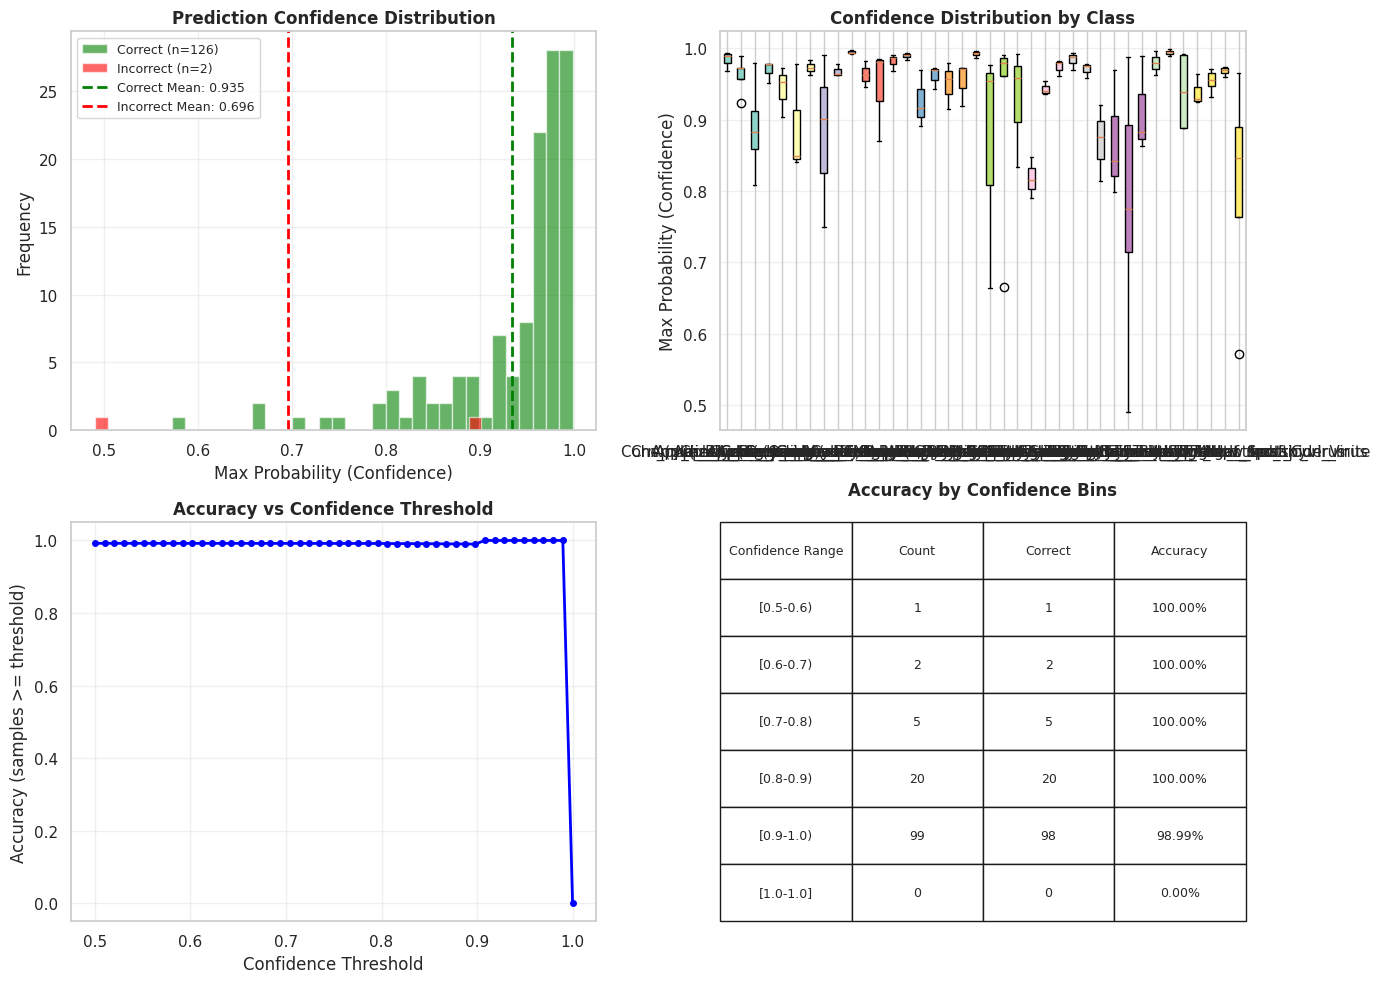

In [56]:
max_confidence = np.max(y_pred_proba, axis=1)
is_correct     = y_pred == y_true

confidence_correct   = max_confidence[is_correct]
confidence_incorrect = max_confidence[~is_correct]

print("=" * 60)
print("CONFIDENCE ANALYSIS")
print("=" * 60)
print(f"Correct predictions   — Mean confidence: {np.mean(confidence_correct):.4f}")
print(f"Incorrect predictions — Mean confidence: {np.mean(confidence_incorrect):.4f}")
print(f"Confidence gap:                          {np.mean(confidence_correct) - np.mean(confidence_incorrect):.4f}")
print(f"Total correct: {np.sum(is_correct)} / {len(y_true)}")
print(f"Overall accuracy (test set): {np.sum(is_correct) / len(y_true):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(confidence_correct,   bins=30, alpha=0.6, label=f"Correct (n={len(confidence_correct)})",   color="green")
axes[0, 0].hist(confidence_incorrect, bins=30, alpha=0.6, label=f"Incorrect (n={len(confidence_incorrect)})", color="red")
axes[0, 0].axvline(np.mean(confidence_correct),   color="green", linestyle="--", linewidth=2,
                   label=f"Correct Mean: {np.mean(confidence_correct):.3f}")
axes[0, 0].axvline(np.mean(confidence_incorrect), color="red",   linestyle="--", linewidth=2,
                   label=f"Incorrect Mean: {np.mean(confidence_incorrect):.3f}")
axes[0, 0].set_title("Prediction Confidence Distribution", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Max Probability (Confidence)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(alpha=0.3)

confidence_by_class = []
class_labels_plot   = []
for i, cn in enumerate(class_names):
    mask = y_true == i
    if np.sum(mask) > 0:
        confidence_by_class.append(max_confidence[mask])
        class_labels_plot.append(cn)

bp = axes[0, 1].boxplot(confidence_by_class, labels=class_labels_plot, patch_artist=True)
for patch, color in zip(bp["boxes"], plt.cm.Set3(np.linspace(0, 1, len(class_labels_plot)))):
    patch.set_facecolor(color)
axes[0, 1].set_title("Confidence Distribution by Class", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Max Probability (Confidence)")
axes[0, 1].grid(alpha=0.3, axis="y")

thresholds = np.linspace(0.5, 1.0, 50)
accuracies = []
for threshold in thresholds:
    mask = max_confidence >= threshold
    accuracies.append(np.sum(is_correct[mask]) / np.sum(mask) if np.sum(mask) > 0 else 0)

axes[1, 0].plot(thresholds, accuracies, "o-", linewidth=2, markersize=4, color="blue")
axes[1, 0].set_title("Accuracy vs Confidence Threshold", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Confidence Threshold")
axes[1, 0].set_ylabel("Accuracy (samples >= threshold)")
axes[1, 0].grid(alpha=0.3)

bins     = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
bin_data = []
for i in range(len(bins) - 1):
    mask    = (max_confidence >= bins[i]) & (max_confidence < bins[i + 1])
    count   = np.sum(mask)
    correct = np.sum(is_correct[mask])
    acc     = correct / count if count > 0 else 0
    bin_data.append({"Confidence Range": f"[{bins[i]:.1f}-{bins[i+1]:.1f})",
                     "Count": count, "Correct": correct, "Accuracy": f"{acc:.2%}"})
mask    = max_confidence >= bins[-1]
count   = np.sum(mask)
correct = np.sum(is_correct[mask])
acc     = correct / count if count > 0 else 0
bin_data.append({"Confidence Range": f"[{bins[-1]:.1f}-1.0]",
                 "Count": count, "Correct": correct, "Accuracy": f"{acc:.2%}"})

bin_df = pd.DataFrame(bin_data)
axes[1, 1].axis("off")
bin_table = axes[1, 1].table(cellText=bin_df.values, colLabels=bin_df.columns,
                              cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
bin_table.auto_set_font_size(False)
bin_table.set_fontsize(9)
bin_table.scale(1, 2.5)
axes[1, 1].set_title("Accuracy by Confidence Bins", fontsize=12, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(EVAL_OUTPUT_DIR / "prediction_confidence_analysis.png", dpi=200, bbox_inches="tight")
plt.show()
bin_df.to_csv(EVAL_OUTPUT_DIR / "confidence_bins_analysis.csv", index=False)

## C_Best, C_Second_Best, C_True — Triangle Plots

For each split, we extract three confidence values per sample:
- **C_best**: highest class probability
- **C_second**: second-highest class probability
- **C_true**: probability assigned to the ground-truth class

[Traning] Top-1 Accuracy: 0.9978   Top-2 Accuracy: 0.9999


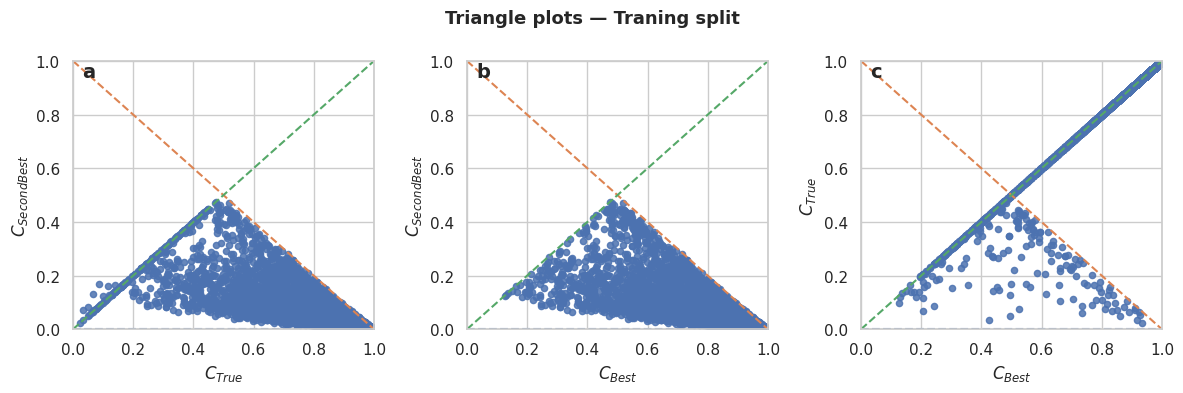

[Validation] Top-1 Accuracy: 0.9953   Top-2 Accuracy: 0.9995


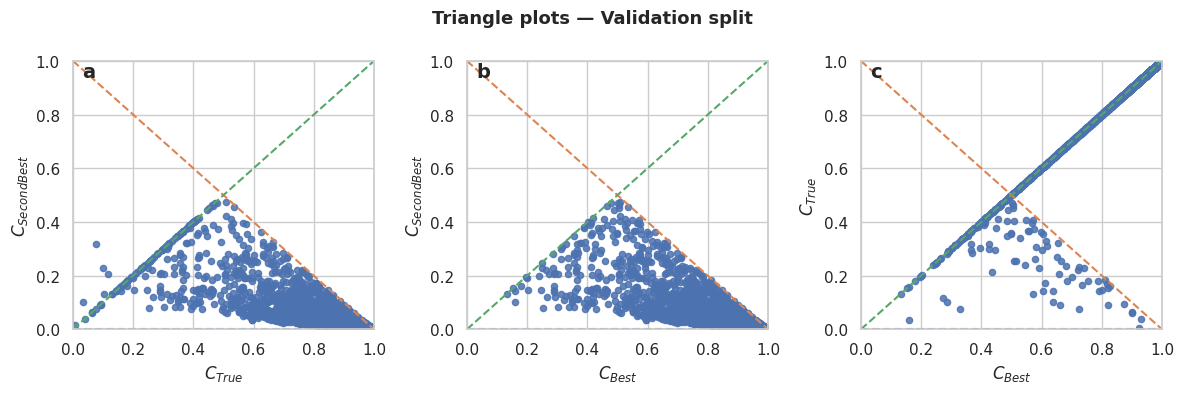

[Test] Top-1 Accuracy: 0.9844   Top-2 Accuracy: 1.0000


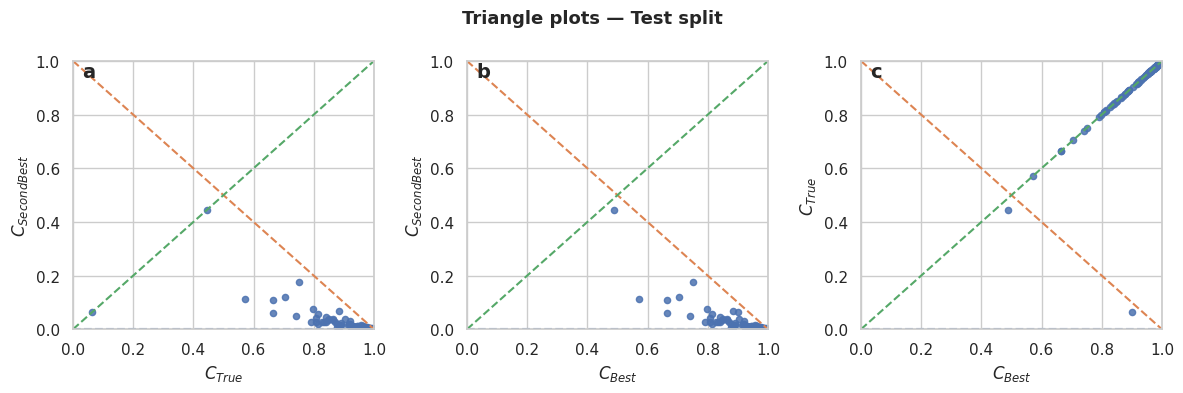

In [60]:
def triangle_plot(x, y, xlabel, ylabel, panel):
    plt.scatter(x, y, s=20, alpha=0.85)
    plt.plot([0, 1], [0, 0], linestyle='--')   # bottom
    plt.plot([0, 1], [1, 0], linestyle='--')   # hypotenuse
    plt.plot([0, 1], [0, 1], linestyle='--')   # diagonal reference
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.text(0.03, 0.94, panel, fontsize=14, fontweight='bold')


def run_triangle_analysis(dataset, split_label):
    """Compute and plot C_best / C_second / C_true triangle plots for a dataset split."""
    y_prob_split = model.predict(dataset, verbose=0)

    y_true_split = np.concatenate(
        [y.numpy() for _, y in dataset], axis=0
    )
    y_true_idx_split = np.argmax(y_true_split, axis=1)

    # Top-1 and Top-2
    top1_idx = np.argmax(y_prob_split, axis=1)
    top2_idx = np.argsort(y_prob_split, axis=1)[:, -2]

    top1_correct = (y_true_idx_split == top1_idx)
    top2_correct = (y_true_idx_split == top2_idx)
    top1_acc     = np.mean(top1_correct)
    top2_acc     = np.mean(top1_correct | top2_correct)
    print(f"[{split_label}] Top-1 Accuracy: {top1_acc:.4f}   Top-2 Accuracy: {top2_acc:.4f}")

    sorted_probs = np.sort(y_prob_split, axis=1)
    C_best   = sorted_probs[:, -1]
    C_second = sorted_probs[:, -2]
    C_true   = y_prob_split[np.arange(len(y_true_idx_split)), y_true_idx_split]

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Triangle plots — {split_label} split", fontsize=13, fontweight='bold')

    plt.subplot(1, 3, 1)
    triangle_plot(C_true, C_second,
                  r"$C_{True}$", r"$C_{SecondBest}$", "a")

    plt.subplot(1, 3, 2)
    triangle_plot(C_best, C_second,
                  r"$C_{Best}$", r"$C_{SecondBest}$", "b")

    plt.subplot(1, 3, 3)
    triangle_plot(C_best, C_true,
                  r"$C_{Best}$", r"$C_{True}$", "c")

    plt.tight_layout()
    plt.savefig(EVAL_OUTPUT_DIR / f"triangle_plots_{split_label.lower()}.png",
                dpi=200, bbox_inches="tight")
    plt.show()

run_triangle_analysis(training_set,        "Traning")
run_triangle_analysis(validation_set,  "Validation")
run_triangle_analysis(test_set,        "Test")

## Second-Best Prediction Analysis

Analyses how often the true class is the second-best prediction when the top-1 prediction is wrong.

In [61]:
def analyze_second_best_predictions(dataset, split_label):
    y_prob_split = model.predict(dataset, verbose=0)
    y_true_split = np.concatenate([y.numpy() for _, y in dataset], axis=0)
    y_true_idx_split = np.argmax(y_true_split, axis=1)

    top1_idx = np.argmax(y_prob_split, axis=1)
    top2_idx = np.argsort(y_prob_split, axis=1)[:, -2]

    is_correct        = (y_true_idx_split == top1_idx)
    second_best_is_true = (~is_correct) & (y_true_idx_split == top2_idx)

    total             = len(y_true_idx_split)
    n_incorrect       = int(np.sum(~is_correct))
    n_second_correct  = int(np.sum(second_best_is_true))

    print(f"\n{'='*60}")
    print(f"SECOND BEST PREDICTION ANALYSIS — {split_label}")
    print('='*60)
    print(f"Total samples:            {total}")
    print(f"Incorrect predictions:    {n_incorrect}")
    print(f"2nd-best == true class:   {n_second_correct}")
    if n_incorrect > 0:
        pct = n_second_correct / n_incorrect * 100
        print(f"% of incorrect recovered by 2nd-best: {pct:.2f}%")

    # Misclassification patterns
    if n_incorrect > 0:
        print("\nTop misclassification patterns (true → predicted):")
        true_names  = [class_names[i] for i in y_true_idx_split[~is_correct]]
        pred_names  = [class_names[i] for i in top1_idx[~is_correct]]
        pattern_series = pd.Series(
            [f"{t} → {p}" for t, p in zip(true_names, pred_names)]
        ).value_counts().head(10)
        for pattern, count in pattern_series.items():
            print(f"  {pattern}: {count}")

analyze_second_best_predictions(training_set,       "Traning")
analyze_second_best_predictions(validation_set, "Validation")
analyze_second_best_predictions(test_set,       "Test")


SECOND BEST PREDICTION ANALYSIS — Traning
Total samples:            70295
Incorrect predictions:    157
2nd-best == true class:   149
% of incorrect recovered by 2nd-best: 94.90%

Top misclassification patterns (true → predicted):
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → Corn_(maize)___Northern_Leaf_Blight: 29
  Corn_(maize)___Northern_Leaf_Blight → Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 18
  Tomato___Tomato_Yellow_Leaf_Curl_Virus → Tomato___Bacterial_spot: 18
  Potato___healthy → Pepper,_bell___healthy: 14
  Tomato___Early_blight → Tomato___Late_blight: 11
  Tomato___Spider_mites Two-spotted_spider_mite → Tomato___Target_Spot: 10
  Tomato___Tomato_Yellow_Leaf_Curl_Virus → Tomato___Spider_mites Two-spotted_spider_mite: 6
  Squash___Powdery_mildew → Orange___Haunglongbing_(Citrus_greening): 4
  Apple___Apple_scab → Apple___healthy: 3
  Tomato___Bacterial_spot → Tomato___Target_Spot: 3

SECOND BEST PREDICTION ANALYSIS — Validation
Total samples:            175

## Single Image Prediction

Input shape: (1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted class: Tomato___Tomato_Yellow_Leaf_Curl_Virus  (confidence: 0.8022)


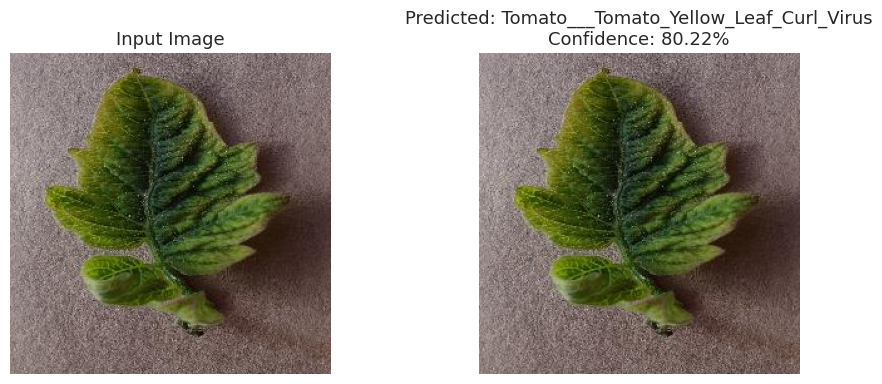

In [62]:
import cv2

IMG_DIR = Path("/content/drive/MyDrive/test_images")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Replace with your image path
# image_path = IMG_DIR / 'AppleCedarRust1.JPG'
# image_path = IMG_DIR / 'CornCommonRust2.JPG'
# image_path = IMG_DIR / 'PotatoHealthy1.JPG'
image_path = IMG_DIR / 'TomatoYellowCurlVirus1.JPG'

# Display the image
img = cv2.imread(str(image_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess — must match IMG_SIZE used in training
input_img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
input_arr = tf.keras.preprocessing.image.img_to_array(input_img)
input_arr = np.expand_dims(input_arr, axis=0)   # add batch dimension
print("Input shape:", input_arr.shape)           # expect (1, 224, 224, 3)

prediction       = model.predict(input_arr)
result_index     = np.argmax(prediction)
model_prediction = class_names[result_index]
confidence       = prediction[0, result_index]

print(f"Predicted class: {model_prediction}  (confidence: {confidence:.4f})")

# Side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img)
axes[0].set_title("Input Image", fontsize=13)
axes[0].axis("off")

axes[1].imshow(img)
axes[1].set_title(f"Predicted: {model_prediction}\nConfidence: {confidence:.2%}", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()